# COMP1032 COURSEWORK

### Library Imports

In [114]:
import numpy as np
from skimage import io
import matplotlib.pyplot as plt
from skimage.transform import rotate, resize

import heapq
import csv
import itertools
import time
import tracemalloc
from collections import deque
from dataclasses import dataclass, field
from pathlib import Path
import cv2

try:
    from skimage.transform import hough_line, hough_line_peaks
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False

# Section A

### Weiqi Loo

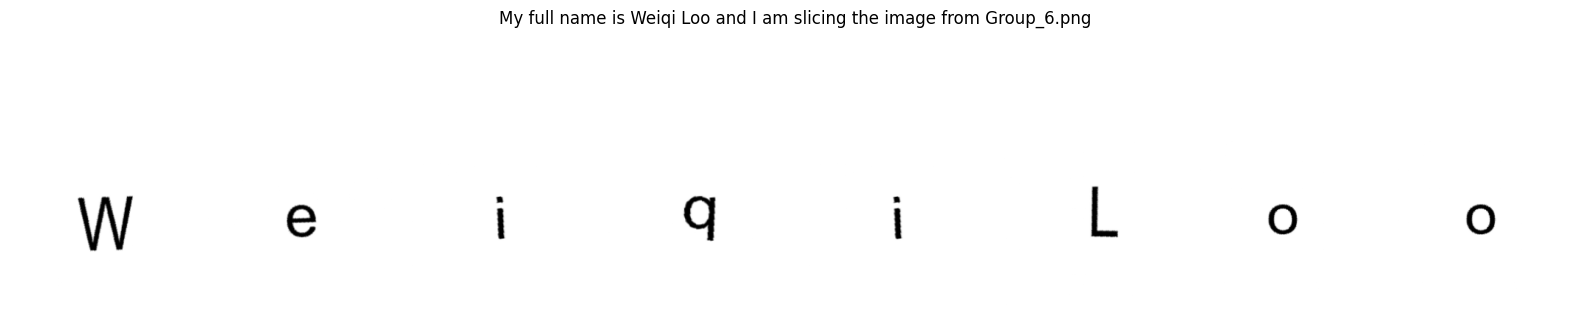

In [116]:
img = io.imread('Image/Group_6.png')

vcols = [0, 222, 444, 666, 888, 1110, 1332, 1554, 1776, 1998]
hrows = [0, 166, 332, 498, 664, 830, 996]

def get_letter(row, col, trim=8, angle=0, output_shape=(200, 200)):
    letter = img[hrows[row]+trim:hrows[row+1]-trim, #grid slicing
                 vcols[col]+trim:vcols[col+1]-trim]
    if angle != 0:
        letter = rotate(letter, angle, resize=True, cval=1.0) #adjust rotation
        
    letter_resized = resize(letter, output_shape, anti_aliasing=True)
    return letter_resized
    
letters = [
    get_letter(2, 4, angle=337.5, output_shape=(270, 250)),  # W
    get_letter(5, 2, angle=-20,   output_shape=(210, 250)),  # e
    get_letter(1, 0, angle=10,    output_shape=(180, 250)),  # i
    get_letter(3, 7, angle=5,     output_shape=(168, 250)),  # q
    get_letter(1, 0, angle=10,    output_shape=(180, 250)),  # i
    get_letter(5, 1, angle=29,    output_shape=(270, 250)),  # L
    get_letter(1, 1, angle=207.5, output_shape=(210, 250)),  # o
    get_letter(1, 1, angle=207.5, output_shape=(210, 250))   # o
]

fig, axes = plt.subplots(1, 8, figsize=(16, 4))
fig.suptitle('My full name is Weiqi Loo and I am slicing the image from Group_6.png', fontsize=12)

for ax, letter in zip(axes, letters):
    ax.imshow(letter)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Hao Yin Ng

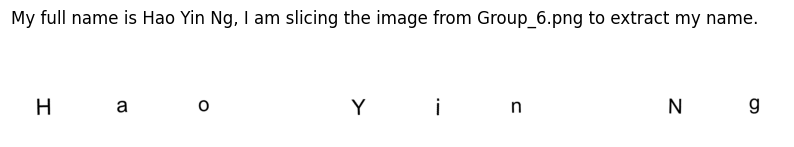

In [ ]:
# Load the image
img = io.imread('Image/Group_6.png')

# Calculate spaces for 6 rows and 9 columns
total_height = img.shape[0]
total_width = img.shape[1]
cell_h = total_height // 6
cell_w = total_width // 9

# Slicing function
def get_letter(row, col, angle):
    offset=5
    letter = img[row * cell_h + offset : (row + 1) * cell_h - offset, col * cell_w + offset : (col + 1) * cell_w - offset]
    straight_letter = rotate(letter, angle=angle, resize=True, cval=1)
    return straight_letter


# Extracting H(4,8), a(1,2), o(1,1), Y(0,7), i(1,0), n(0,2), N(4,5), g(0,5)
letter_H = get_letter(4, 8, angle=-10)
letter_a = get_letter(1, 2, angle=-20)
letter_o = get_letter(1, 1, angle=30)
letter_Y = get_letter(0, 7, angle=15)
letter_i = get_letter(1, 0, angle=7)
letter_n = get_letter(0, 2, angle=-25)
letter_N = get_letter(4, 5, angle=25)
letter_g = get_letter(0, 5, angle=30)
# Extracting a blank white cell for the space
blank_space = get_letter(5, 8, angle=0)

# Make a figure that fits 10 items
plt.figure(figsize=(10, 2))

plt.subplot(1, 10, 1); plt.imshow(letter_H); plt.axis('off')
plt.subplot(1, 10, 2); plt.imshow(letter_a); plt.axis('off')
plt.subplot(1, 10, 3); plt.imshow(letter_o); plt.axis('off')
plt.subplot(1, 10, 4); plt.imshow(blank_space); plt.axis('off')
plt.subplot(1, 10, 5); plt.imshow(letter_Y); plt.axis('off')
plt.subplot(1, 10, 6); plt.imshow(letter_i); plt.axis('off')
plt.subplot(1, 10, 7); plt.imshow(letter_n); plt.axis('off')
plt.subplot(1, 10, 8); plt.imshow(blank_space); plt.axis('off')
plt.subplot(1, 10, 9); plt.imshow(letter_N); plt.axis('off')
plt.subplot(1, 10, 10); plt.imshow(letter_g); plt.axis('off')

plt.suptitle('My full name is Hao Yin Ng, I am slicing the image from Group_6.png to extract my name.', fontsize=12)
plt.show()

### Mohamed Amin Mohamed Osman

In [ ]:
# Load the source image containing the alphabet grid
img = io.imread('Image/Group_6.png')

# Define grid dimensions (6 rows by 9 columns)
rows, cols = 6, 9
h, w, _ = img.shape

# Calculate the size of each individual cell in the grid
cell_h, cell_w = h // rows, w // cols

# Margin to crop out borders/noise from each letter cell
margin = 8 

In [ ]:
def get_letter(r, c, angle=0, flip_v=False, flip_h=False):
    # Extracts a specific letter from the grid and applies transformations.
    # r, c: Row and column index in the grid
    # angle: Degree of rotation
    # flip_v/flip_h: For vertical or horizontal mirroring

    # Slice the image based on row/column indices and apply margins
    letter = img[r*cell_h + margin : (r+1)*cell_h - margin, 
                 c*cell_w + margin : (c+1)*cell_w - margin]
    
    # Apply mirroring/flipping if requested
    if flip_v: letter = letter[::-1, :]
    if flip_h: letter = letter[:, ::-1]

    # Handle rotation    
    if angle != 0:
        # Rotate image; cval=1 ensures the background remains white (for 0-1 float range)
        letter = rotate(letter, angle, resize=False, mode='constant', cval=1)
        # Convert back to 8-bit integer format for consistent plotting
        letter = (letter * 255).astype(np.uint8)
        
    return letter

In [ ]:
# Mapping individual letters to their coordinates in Group_6.png
first_name = [
    get_letter(0, 8, angle=332),                            # M
    get_letter(1, 1, angle=25),                             # o
    get_letter(0, 0, angle=153, flip_v=True, flip_h=True),  # h
    get_letter(1, 2, angle=340),                            # a
    get_letter(1, 6, angle=12),                             # m
    get_letter(5, 2, angle=340),                            # e
    get_letter(2, 1, angle=210, flip_v=True, flip_h=True),  # d
    None,                                                   # Small gap within "Mohamed Amin"
    get_letter(4, 4, angle=345),                            # A
    get_letter(1, 6, angle=12),                             # m
    get_letter(1, 0, angle=10),                             # i
    get_letter(0, 2, angle=155, flip_v=True, flip_h=True)   # n
]

last_name = [
    get_letter(0, 8, angle=332),                            # M
    get_letter(1, 1, angle=25),                             # o
    get_letter(0, 0, angle=153, flip_v=True, flip_h=True),  # h
    get_letter(1, 2, angle=340),                            # a
    get_letter(1, 6, angle=12),                             # m
    get_letter(5, 2, angle=340),                            # e
    get_letter(2, 1, angle=210, flip_v=True, flip_h=True),  # d
    None,                                                   # Small gap within "Mohamed Osman"
    get_letter(1, 3, angle=19),                             # O
    get_letter(3, 0, angle=0),                              # s
    get_letter(1, 6, angle=12),                             # m
    get_letter(1, 2, angle=340),                            # a
    get_letter(0, 2, angle=155, flip_v=True, flip_h=True)   # n
]

# Combine lists with a large gap (3 None entries) between names
full_display_list = first_name + [None] * 3 + last_name

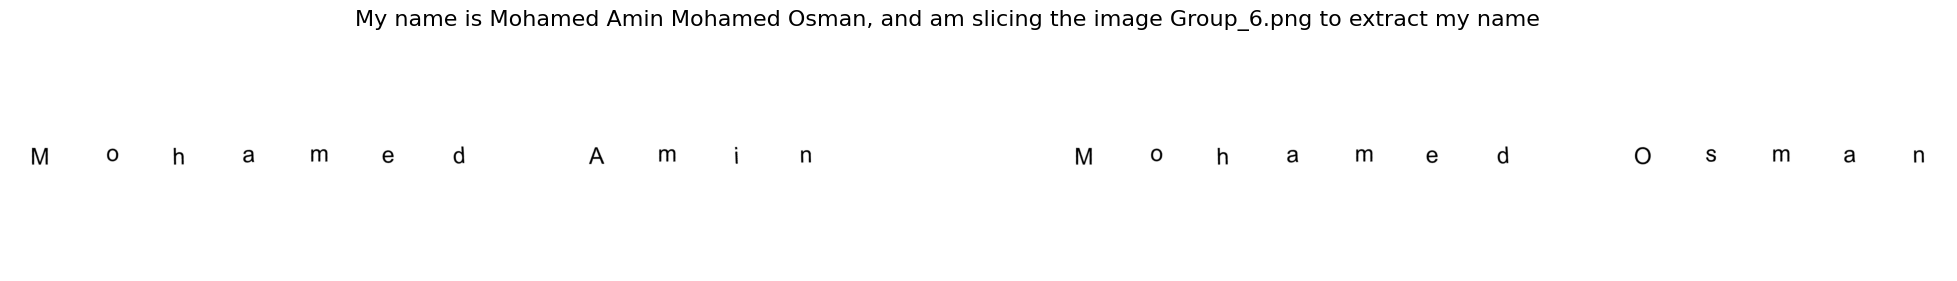

In [ ]:
# Create a wide figure to accommodate the full name
plt.figure(figsize=(25, 3))
for i, letter in enumerate(full_display_list):
    # Dynamically create subplots for each letter in the list
    plt.subplot(1, len(full_display_list), i + 1)
    if letter is not None:
        plt.imshow(letter)
    plt.axis('off') # Hide axes for a cleaner look

# Title describing the assignment task
plt.suptitle("My name is Mohamed Amin Mohamed Osman, and am slicing the image Group_6.png to extract my name", fontsize=16)
plt.show()


### YoonJae Lee

In [ ]:
img = io.imread("Image/Group_6.png")
rows, cols = 6, 9
h, w = img.shape[0], img.shape[1]
cell_h = h // rows
cell_w = w // cols

In [ ]:
# Slice one letter from the grid using row r, column c (Lab 4.1: img[y1:y2, x1:x2])
def get_letter(r, c, margin=6):
    y1 = r * cell_h + margin
    y2 = min((r + 1) * cell_h, h) - margin
    x1 = c * cell_w + margin
    x2 = min((c + 1) * cell_w, w) - margin
    return img[y1:y2, x1:x2]

In [ ]:
# Crop each patch to the same height and width (take the smallest size, cut from the middle)
def crop_to_size(patch, out_h, out_w):
    ph, pw = patch.shape[0], patch.shape[1]
    y0 = max(0, (ph - out_h) // 2)
    x0 = max(0, (pw - out_w) // 2)
    return patch[y0 : y0 + out_h, x0 : x0 + out_w]

In [ ]:
FIRST = [(0, 7), (1, 1), (1, 1), (0, 2), (3, 8), (1, 2), (5, 2)]
LAST = [(5, 1), (5, 2), (5, 2)]
MARGIN = 6

# Rotation fixes for visibly tilted letters in Group_6
ROT = {
    (0, 7): 15,   # Y
    (5, 1): 30,   # L
    (1, 1): 30,   # o
    (1, 2): -20,  # a
    (5, 2): -20,  # e
    (0, 2): -24,  # n
    (3, 8): -10,   # j
}

def rotate_letter(patch, angle=0):
    if angle == 0:
        return patch
    r = rotate(patch, angle, resize=False, mode="constant", cval=1.0)
    return (np.clip(r, 0, 1) * 255).astype(np.uint8)

def get_processed(r, c):
    p = get_letter(r, c, MARGIN)
    p = rotate_letter(p, ROT.get((r, c), 0))
    return p

used = set(FIRST + LAST)
patches = [get_processed(r, c) for r, c in used]
out_h = min(p.shape[0] for p in patches)
out_w = min(p.shape[1] for p in patches)

first_letters = [crop_to_size(get_processed(r, c), out_h, out_w) for r, c in FIRST]
last_letters = [crop_to_size(get_processed(r, c), out_h, out_w) for r, c in LAST]

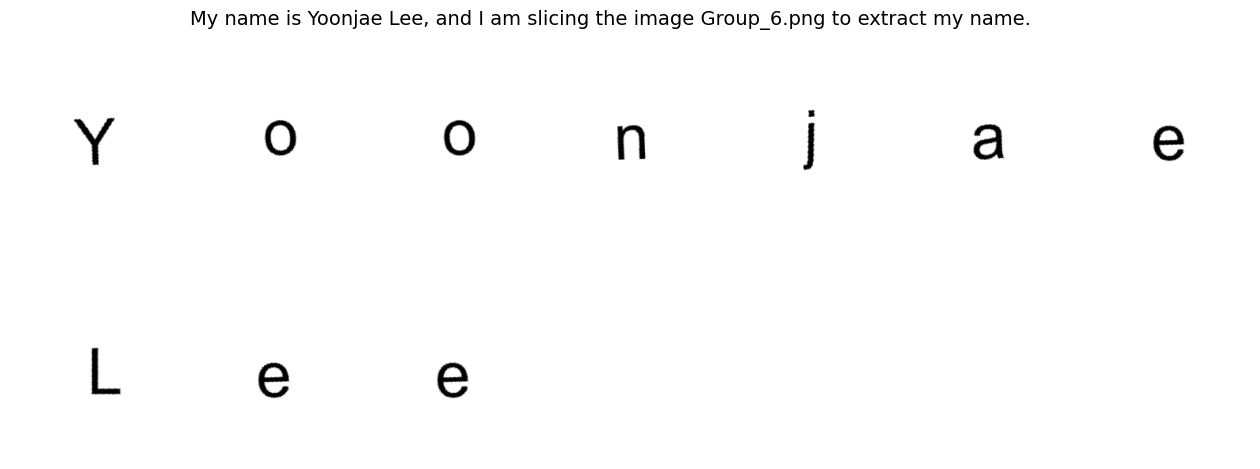

In [ ]:
# One figure: first name row, then last name row
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(2, 7, height_ratios=[1, 1], hspace=0.45, top=0.88, bottom=0.08)

fig.suptitle(
    "My name is Yoonjae Lee, and I am slicing the image Group_6.png to extract my name.",
    fontsize=14,
)

for i, patch in enumerate(first_letters):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(np.clip(patch, 0, 255).astype(np.uint8))
    ax.axis("off")

for i, patch in enumerate(last_letters):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(np.clip(patch, 0, 255).astype(np.uint8))
    ax.axis("off")

for j in range(len(last_letters), 7):
    ax = fig.add_subplot(gs[1, j])
    ax.axis("off")


plt.subplots_adjust(wspace=0.08)
plt.show()

# Section B

# Section B — Finding the A4: A Search-Based Approach

## Problem Formulation

The goal of this section is to locate an A4 sheet of paper in a cluttered real-world 
image using the **A\* search algorithm**.

### State Space Definition
- **State `s`:** An ordered sequence of `k` detected corner points, where `k ∈ {0,1,2,3,4}`
- **Initial State:** An empty sequence `()` — no corners selected
- **Goal State:** A sequence of exactly 4 corners that forms a valid quadrilateral 
  with a high A4 likelihood score

### Successor Function
A new candidate point `p` is added to the state if:
1. **Uniqueness:** `p` is not already in the current state
2. **Angle Constraint (k ≥ 2):** The interior angle at the last point must be 
   between 75° and 105° (approximately 90°)
3. **Ratio Constraint (k = 3):** The implied quadrilateral's long/short side ratio 
   must fall between 1.25 and 1.60 (A4 is ~1.414)

### Pipeline Overview
1. **Preprocessing** — Image is standardised, edges are detected via DoG + Canny, 
   and Hough line intersections are extracted as candidate corner points
2. **Search** — A\* explores the state space using geometric constraints to prune 
   invalid paths
3. **Scoring** — Each complete 4-point state is scored by `likelihoodA4()`, which 
   measures both edge alignment and A4 aspect ratio
4. **Evaluation** — BFS, A\* with h1, and A\* with h2 are benchmarked and compared 
   across the full image dataset

In [ ]:
# # Standardized resolution to ensure consistent feature detection across all input images
target_height = 1400
target_width = 1050

### A4 Document Likelihood Function

In [ ]:
# Likelihood function: scores a candidate rectangle based on edge alignment and A4 aspect ratio.
def likelihoodA4(rect, bw, weightA4Prior=0.6, neighborhood=1):

    if rect.shape != (4, 2):
        raise ValueError("rect should be 4x2 array.")
    
    image_height, image_width = bw.shape
    p_edge = 0.0

    # Check if the lines between corners align with edges in the image
    for i in range(4):
        pt1, pt2 = rect[i], rect[(i + 1) % 4]
        if np.allclose(pt1, pt2):
            return 0.0
        
        # Sample points along the line segment to check for overlap with edges
        x1, y1 = pt1
        x2, y2 = pt2
        n = 200
        xs = np.rint(np.linspace(x1, x2, n)).astype(int)
        ys = np.rint(np.linspace(y1, y2, n)).astype(int)
        pts = np.unique(np.column_stack((ys, xs)), axis=0)

        # Check neighboring pixels to allow for slight blur/error
        if neighborhood > 0:
            expanded = []
            for (r, c) in pts:
                if neighborhood == 1:
                    neigh = [(r, c), (r + 1, c), (r - 1, c), (r, c + 1), (r, c - 1)]
                else:
                    neigh = [
                        (r, c), (r + 1, c), (r - 1, c), (r, c + 1), (r, c - 1),
                        (r + 1, c + 1), (r - 1, c + 1), (r + 1, c - 1), (r - 1, c - 1),
                    ]
                expanded.extend(neigh)
            pts = np.unique(np.array(expanded), axis=0)

        # Ensure points are within the image frame
        inb = (
            (pts[:, 0] >= 0) & (pts[:, 0] < image_height) &
            (pts[:, 1] >= 0) & (pts[:, 1] < image_width)
        )
        pts = pts[inb]
        
        if len(pts) == 0:
            return 0.0
        p_edge += np.sum(bw[pts[:, 0], pts[:, 1]]) / float(len(pts))

    p_edge /= 4.0

    # Check if the rectangle matches the A4 height-to-width ratio
    v1, v2, v3, v4 = rect[0] - rect[1], rect[1] - rect[2], rect[2] - rect[3], rect[3] - rect[0]
    n1, n2, n3, n4 = np.linalg.norm(v1), np.linalg.norm(v2), np.linalg.norm(v3), np.linalg.norm(v4)

    if min(n1, n2, n3, n4) < 1e-6:
        return 0.0
    
    if n1 > n2:
        ratio1, ratio2 = n1 / n2, n3 / n4
    else:
        ratio1, ratio2 = n2 / n1, n4 / n3
    ratio = (ratio1 + ratio2) / 2.0

    # Gaussian score for A4 ratio (approx 1.414)
    mu, sigma = 297.0 / 210.0, 0.5
    q = np.exp(-((ratio - mu) ** 2) / (2 * sigma ** 2)) / (np.sqrt(2 * np.pi) * sigma)
    return (1 - weightA4Prior) * p_edge + weightA4Prior * q

### Image Pre-processing & Candidate Generation

In [ ]:
# Cleans image and finds line intersections as corner candidates
def preprocess_candidates(filepath, n_hough_peaks=80, angle_l=15, angle_h=75, max_candidates=120):
    img = cv2.imread(str(filepath))
    if img is None:
        raise IOError(f"Cannot read image: {filepath}")

    # Standardize image orientation and size
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if gray.shape[0] < gray.shape[1]:
        gray = np.rot90(gray, k=3)
    gray = cv2.resize(gray, (target_width, target_height), interpolation=cv2.INTER_AREA)

    # Use Difference of Gaussians to isolate page borders
    gray_f = gray.astype(np.float32)
    g1 = cv2.GaussianBlur(gray_f, (21, 21), 20)
    g2 = cv2.GaussianBlur(gray_f, (21, 21), 35)
    dog = g1 - g2
    norm = (255.0 * (dog - dog.min()) / (dog.max() - dog.min() + 1e-8)).astype(np.uint8)

    # Generate binary mask and edge map
    _, binary = cv2.threshold(norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = cv2.erode(binary, np.ones((3, 3), np.uint8))
    _edges = cv2.Canny(binary, 50, 150)
    _edges = cv2.dilate(_edges, np.ones((3, 3), np.uint8))
    edge_mask = (_edges > 0).astype(np.float32)

    # Find Line Peaks, Detect strong lines in the binary image
    if HAS_SKIMAGE:
        tested_angles = np.deg2rad(np.arange(-90, 90, 0.5))
        hspace, angles, dists = hough_line(binary > 0, theta=tested_angles)
        _, theta_peaks, dist_peaks = hough_line_peaks(
            hspace, angles, dists, num_peaks=n_hough_peaks, threshold=0.1 * np.max(hspace)
        )
    else:
        edges = cv2.Canny(binary, 50, 150)
        lines = cv2.HoughLines(edges, 1, np.pi / 360.0, 60)

        if lines is None:
            return [], edge_mask, gray.shape[1], gray.shape[0]
        lines = lines[: min(n_hough_peaks, len(lines)), 0, :]
        dist_peaks = lines[:, 0]
        theta_peaks = lines[:, 1]

    # Filter lines: remove horizontal/vertical lines that might be noise
    deg_thetas = np.rad2deg(theta_peaks)
    keep = [
        not ((th >= -angle_h and th <= -angle_l) or (th >= angle_l and th <= angle_h))
        for th in deg_thetas
    ]
    theta_peaks = theta_peaks[keep]
    dist_peaks = dist_peaks[keep]
    image_h, image_w = gray.shape

    # Calculate intersections, Line intersections provide corner candidates
    points = []
    for i in range(len(dist_peaks)):
        rho1, theta1 = dist_peaks[i], theta_peaks[i]
        for j in range(i + 1, len(dist_peaks)):
            rho2, theta2 = dist_peaks[j], theta_peaks[j]
            if np.isclose(theta1, theta2, atol=1e-6):
                continue

            A = np.array([[np.cos(theta1), np.sin(theta1)], [np.cos(theta2), np.sin(theta2)]])
            b = np.array([rho1, rho2])
            try:
                x_sol, y_sol = np.linalg.solve(A, b)
            except np.linalg.LinAlgError:
                continue

            # Slightly wider bounds so we do not over-filter real corners.
            if not (image_w * 0.05 < x_sol < image_w * 0.95):
                continue
            if not (image_h * 0.05 < y_sol < image_h * 0.90):
                continue
            points.append((int(round(x_sol)), int(round(y_sol))))

    candidates = list(set(points))

    # Fallback: if no line intersections are found, use corner feature detection
    if len(candidates) == 0:
        corners = cv2.goodFeaturesToTrack(binary, maxCorners=max_candidates, qualityLevel=0.01, minDistance=10)
        if corners is not None:
            candidates = [(int(c[0][0]), int(c[0][1])) for c in corners]

    # Simplify candidates: use K-means to group points that are very close together
    if len(candidates) > max_candidates:
        data = np.array(candidates, dtype=np.float32)
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
        _, _, centers = cv2.kmeans(data, max_candidates, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
        candidates = [(int(round(p[0])), int(round(p[1]))) for p in centers]
        
    return candidates, edge_mask, image_w, image_h

### Geometric Successor Rules

In [ ]:
# Helper function to calculate the interior angle between two vectors
def _angle(v1, v2):
    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)
    # Handle zero-length vectors to avoid division by zero
    if n1 < 1e-6 or n2 < 1e-6:
        return 180.0
    
    # Calculate angle using dot product (clipped for numerical stability)
    c = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
    return np.degrees(np.arccos(c))


# Validates if a candidate point can be added to the current search state
def valid_next(state, pt, image_w, image_h):
    # Prevent self-intersection by ensuring points are unique
    if pt in state:
        return False
        
    k = len(state)
    
    # When 3 points are selected, the angle formed must be roughly 90 degrees (75° to 105°)
    if k >= 2:
        p0 = np.array(state[-2], dtype=float)
        p1 = np.array(state[-1], dtype=float)
        p2 = np.array(pt, dtype=float)
        ang = _angle(p0 - p1, p2 - p1)
        if not (75.0 <= ang <= 105.0): # 
            return False

    # Once 4 points are selected, the resulting shape must resemble A4 proportions
    if k == 3:
        p0, p1, p2 = [np.array(p, dtype=float) for p in state]
        p3 = np.array(pt, dtype=float)
        
        # Calculate side lengths for the candidate quadrilateral
        e1 = np.linalg.norm(p1 - p0)
        e2 = np.linalg.norm(p2 - p1)
        e3 = np.linalg.norm(p3 - p2)
        e4 = np.linalg.norm(p0 - p3)
        
        # Avoid overlapping points
        if min(e1, e2, e3, e4) < 1e-6:
            return False
            
        # Validate side-length ratios (Long Side / Short Side)
        # Using averages helps account for perspective distortion in the image
        long_side = (max(e1, e2) + max(e3, e4)) / 2.0
        short_side = (min(e1, e2) + min(e3, e4)) / 2.0
        ratio = long_side / short_side
        
        # Allow for a tolerance range around the ideal A4 ratio
        if not (1.25 <= ratio <= 1.60): # 
            return False

    return True


# Generates the list of valid next steps for the A* search algorithm
def successors(state, candidates, image_w, image_h):
    # Identifies all candidate points that satisfy the geometric 
    # and structural rules based on the current search state
    return [pt for pt in candidates if valid_next(state, pt, image_w, image_h)]

### Cost Functions, Heuristics, and Node Structure

In [ ]:
def g_uniform(state):
    # Simple cost: just the number of points in the current path.
    return float(len(state))


def _rectangle_deviation(rect):
    """
    Calculates the geometric 'error' of a 4-point shape
    It penalizes deviations from 90-degree angles and the A4 aspect ratio
    """
    p = np.array(rect, dtype=float)
    v1 = p[1] - p[0]
    v2 = p[2] - p[1]
    v3 = p[3] - p[2]
    v4 = p[0] - p[3]
    n1, n2, n3, n4 = np.linalg.norm(v1), np.linalg.norm(v2), np.linalg.norm(v3), np.linalg.norm(v4)

    if min(n1, n2, n3, n4) < 1e-6:
        return 1.0

    # Measures how far the corners are from 90 degrees
    a1 = _angle(-v1, v2)
    a2 = _angle(-v2, v3)
    angle_err = (abs(a1 - 90.0) + abs(a2 - 90.0)) / 180.0

    # Measures how far the shape is from A4 proportions (1.414)
    long_side = (max(n1, n2) + max(n3, n4)) / 2.0
    short_side = (min(n1, n2) + min(n3, n4)) / 2.0
    ratio = long_side / short_side
    ratio_err = abs(ratio - (297.0 / 210.0)) / (297.0 / 210.0)

    return 0.5 * angle_err + 0.5 * ratio_err


def g_penalty(state):
    # Path cost that adds a geometric penalty once a full quadrilateral is formed
    if len(state) < 4:
        return float(len(state))
    return float(len(state)) + _rectangle_deviation(state)


def h1(state):
    # Returns the number of points still needed to reach 4
    return float(4 - len(state))


def _edge_confidence(state, bw_image, image_w, image_h):
    # Measures how well the current segments align with detected edges in the image
    if len(state) < 2:
        return 0.5
    total_on_edge = 0
    total_sampled = 0
    for i in range(len(state) - 1):
        x1, y1 = state[i]
        x2, y2 = state[i + 1]
        n = max(int(np.hypot(x2 - x1, y2 - y1)), 1)
        xs = np.rint(np.linspace(x1, x2, n)).astype(int)
        ys = np.rint(np.linspace(y1, y2, n)).astype(int)
        valid = (xs >= 0) & (xs < image_w) & (ys >= 0) & (ys < image_h)
        xs, ys = xs[valid], ys[valid]
        if xs.size == 0:
            continue
        total_on_edge += np.sum(bw_image[ys, xs])
        total_sampled += xs.size
    if total_sampled == 0:
        return 0.0
    return float(total_on_edge) / float(total_sampled)


def h2(state, bw_image, image_w, image_h):
    # Biases the search toward paths that follow strong edges
    remaining = float(4 - len(state))
    conf = _edge_confidence(state, bw_image, image_w, image_h)
    return remaining * (1.0 - conf)


@dataclass(order=True)
class Node:
    """
        Represents a search state in the A* algorithm
        f: Total estimated cost (g + h)
        g: Actual cost from the start to this node
    """
    f: float
    g: float
    state: tuple = field(compare=False) # The sequence of points chosen so far
    depth: int = field(compare=False, default=0)

### A* Search, BFS Baselines, and Robust Fallback Strategies

In [ ]:
# Finds the optimal sequence of 4 corners using a Priority Queue
def astar_partBC(candidates, bw_image, image_w, image_h, use_h2=False, cost_option=1, goal_threshold=0.5, max_nodes=5000):
    start = ()
    # Initialize heuristic (h) based on whether edge-confidence (h2) is enabled
    h0 = h2(start, bw_image, image_w, image_h) if use_h2 else h1(start)

    # Priority Queue (open_list) stores Nodes sorted by their estimated total cost (f = g + h)
    open_list = [Node(f=h0, g=0.0, state=start, depth=0)]
    closed = set()
    best_score = 0.0
    best_rect = None
    found = False

    nodes_expanded = 0
    while open_list and nodes_expanded < max_nodes:
        # Expand the node with the lowest 'f' score (Best-First)
        node = heapq.heappop(open_list)
        if node.state in closed:
            continue
        closed.add(node.state)
        nodes_expanded += 1

        # Goal Check: A complete quadrilateral is formed at depth 4
        if node.depth == 4:
            rect = np.array(node.state, dtype=float)
            s = likelihoodA4(rect, bw_image, neighborhood=1)

            # Track the highest-scoring candidate found during the search
            if s > best_score:
                best_score = s
                best_rect = rect
            if s >= goal_threshold:
                found = True
            continue

        # Successor Generation: Explore valid next points based on geometric constraints
        for pt in successors(list(node.state), candidates, image_w, image_h):
            nxt = node.state + (pt,)
            if nxt in closed:
                continue

            # g = cost so far; h = estimated cost to reach the goal
            g = g_uniform(nxt) if cost_option == 1 else g_penalty(nxt)
            h = h2(nxt, bw_image, image_w, image_h) if use_h2 else h1(nxt)
            heapq.heappush(open_list, Node(f=g + h, g=g, state=nxt, depth=len(nxt)))

    return found, best_rect, best_score


# Robust Search Wrapper, Attempts A* first, then falls back to Brute-Force for difficult images
def run_partBC_with_fallback(
    candidates,
    edge_mask,
    image_w,
    image_h,
    use_h2=False,
    goal_threshold=0.25,
    max_nodes=4000,
    exhaustive_pool=12,
):
    found, rect, score = astar_partBC(
        candidates,
        edge_mask,
        image_w,
        image_h,
        use_h2=use_h2,
        cost_option=1,
        goal_threshold=goal_threshold,
        max_nodes=max_nodes,
    )

    # Fallback logic, If A* fails to find a good match, check all combinations of top candidates
    if score >= goal_threshold or len(candidates) < 4:
        return found, rect, score
    
    pool = list(candidates)[: min(exhaustive_pool, len(candidates))]
    best_score = score
    best_rect = rect

    # Iteratively evaluate all 4-point combinations in the candidate pool
    for quad in itertools.combinations(pool, 4):
        pts = np.array(quad, dtype=float)

        # Geometry sorting: Ensure points are ordered by angle for the likelihood function
        c = pts.mean(axis=0)
        ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
        order = np.argsort(ang)
        rect_ord = pts[order]

        s = likelihoodA4(rect_ord, edge_mask, neighborhood=1)
        if s > best_score:
            best_score = s
            best_rect = rect_ord

    found_fb = best_score >= goal_threshold
    return found_fb, best_rect, best_score


def exhaustive_quad_best_likelihood(candidates, edge_mask, exhaustive_pool=12):
    # Brute-force baseline: evaluates all 4-point combinations to find the best score
    if len(candidates) < 4:
        return 0.0
    best = 0.0
    pool = list(candidates)[: min(exhaustive_pool, len(candidates))]
    for quad in itertools.combinations(pool, 4):
        pts = np.array(quad, dtype=float)
        c = pts.mean(axis=0)
        ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
        order = np.argsort(ang)
        rect_ord = pts[order]
        s = likelihoodA4(rect_ord, edge_mask, neighborhood=1)
        if s > best:
            best = s
    return best


# Part D BFS baseline, same successors as Astar so you can compare nodes and time.
def bfs_partD(candidates, bw_image, image_w, image_h, goal_threshold=0.5, max_nodes=20000):
    q = deque([()])
    closed = set()
    nodes_expanded = 0
    max_depth = 0
    best_score = 0.0
    best_rect = None
    found = False

    
    while q and nodes_expanded < max_nodes:
        state = q.popleft()
        if state in closed:
            continue
        closed.add(state)
        depth = len(state)
        max_depth = max(max_depth, depth)
        nodes_expanded += 1

        if depth == 4:
            rect = np.array(state, dtype=float)
            s = likelihoodA4(rect, bw_image, neighborhood=1)
            if s > best_score:
                best_score = s
                best_rect = rect
            if s >= goal_threshold:
                found = True
            continue

        for pt in successors(list(state), candidates, image_w, image_h):
            q.append(state + (pt,))

    return {
        "method": "BFS_h0",
        "found": found,
        "best_rect": best_rect,
        "best_score": best_score,
        "nodes_expanded": nodes_expanded,
        "search_depth": max_depth,
    }


# Part D Astar, use_h2 True means h2, False means h1, same graph as BFS.
def astar_partD(candidates, bw_image, image_w, image_h, use_h2=False, cost_option=1, goal_threshold=0.5, max_nodes=20000):
    start = ()
    h0 = h2(start, bw_image, image_w, image_h) if use_h2 else h1(start)
    open_list = [Node(f=h0, g=0.0, state=start, depth=0)]
    closed = set()
    best_score = 0.0
    best_rect = None
    found = False
    nodes_expanded = 0
    max_depth = 0

    while open_list and nodes_expanded < max_nodes:
        node = heapq.heappop(open_list)
        if node.state in closed:
            continue
        closed.add(node.state)
        nodes_expanded += 1
        max_depth = max(max_depth, node.depth)

        if node.depth == 4:
            rect = np.array(node.state, dtype=float)
            s = likelihoodA4(rect, bw_image, neighborhood=1)
            if s > best_score:
                best_score = s
                best_rect = rect
            if s >= goal_threshold:
                found = True
            continue

        for pt in successors(list(node.state), candidates, image_w, image_h):
            nxt = node.state + (pt,)
            if nxt in closed:
                continue
            g = g_uniform(nxt) if cost_option == 1 else g_penalty(nxt)
            h = h2(nxt, bw_image, image_w, image_h) if use_h2 else h1(nxt)
            heapq.heappush(open_list, Node(f=g + h, g=g, state=nxt, depth=len(nxt)))

    method_name = "Astar_h2" if use_h2 else "Astar_h1"
    return {
        "method": method_name,
        "found": found,
        "best_rect": best_rect,
        "best_score": best_score,
        "nodes_expanded": nodes_expanded,
        "search_depth": max_depth,
    }

### Benchmarking A* Search vs. BFS Baselines

In [ ]:
# One image three runs, blend_exhaustive takes max of search score and that small combo score.
def run_partD_on_image(
    image_path,
    goal_threshold=0.25,
    cost_option=1,
    max_nodes=5000,
    blend_exhaustive=True,
):
    """
    Executes a comparative study of BFS, A* (h1), and A* (h2) on a single test case
    Tracks execution time, memory usage, and node expansion for performance analysis
    """
    candidates, edge_mask, w, h = preprocess_candidates(image_path)

    # Benchmarking baseline: Exhaustive search (if enabled) to find the 'ground truth' score
    ex_best = (
        exhaustive_quad_best_likelihood(candidates, edge_mask)
        if blend_exhaustive and len(candidates) >= 4
        else 0.0
    )

    # Define the set of algorithms to be compared
    methods = [
        ("BFS_h0", lambda: bfs_partD(candidates, edge_mask, w, h, goal_threshold, max_nodes)),
        ("Astar_h1", lambda: astar_partD(candidates, edge_mask, w, h, use_h2=False, cost_option=cost_option, goal_threshold=goal_threshold, max_nodes=max_nodes)),
        ("Astar_h2", lambda: astar_partD(candidates, edge_mask, w, h, use_h2=True, cost_option=cost_option, goal_threshold=goal_threshold, max_nodes=max_nodes)),
    ]

    rows = []
    for _, fn in methods:
        # Resource Monitoring, Start tracking memory and time
        tracemalloc.start()
        t0 = time.time()

        res = fn()

        elapsed = time.time() - t0
        _, mem_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # Performance Logging, Consolidate metrics for the report
        score_search = float(res["best_score"])
        score_out = max(score_search, ex_best) if blend_exhaustive else score_search
        found_out = res["found"] or (score_out >= goal_threshold)

        rows.append({
            "image": Path(image_path).name,
            "method": res["method"],
            "found": found_out,
            "candidates": len(candidates),
            "nodes_expanded": res["nodes_expanded"],
            "execution_time_s": round(elapsed, 4),
            "final_likelihood_score": round(score_out, 4),
            "search_depth": res["search_depth"],
            "memory_kb": round(mem_peak / 1024.0, 2),
        })
    return rows


# Executes the pipeline across the entire dataset
def run_partD_dataset(data_dir, output_csv="partD_results.csv", goal_threshold=0.25, cost_option=1, max_nodes=5000, blend_exhaustive=True):
    # Automates the evaluation process across a folder of images and exports results to CSV
    data_dir = Path(data_dir)
    images = sorted(list(data_dir.glob("*.JPG")))
    all_rows = []

    for img in images:
        print("Processing:", img.name)
        try:
            all_rows.extend(
                run_partD_on_image(
                    img,
                    goal_threshold=goal_threshold,
                    cost_option=cost_option,
                    max_nodes=max_nodes,
                    blend_exhaustive=blend_exhaustive,
                )
            )
        except Exception as e:
            print("  Error:", e)

    # Data Persistence, Save findings for external visualization or report tables
    out_path = data_dir / output_csv
    if all_rows:
        fields = [
            "image", "method", "found", "candidates", "nodes_expanded",
            "execution_time_s", "final_likelihood_score", "search_depth", "memory_kb",
        ]
        with open(out_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fields)
            writer.writeheader()
            writer.writerows(all_rows)
        print("Saved:", out_path)
    return all_rows


def print_partD_summary(rows):
    # Summarizes average performance metrics and highlights the best/worst detection cases.
    if not rows:
        print("No rows to summarize.")
        return

    # Comparative Metric Overview
    methods = sorted(set(r["method"] for r in rows))
    print("\nAverage metrics by method")
    for m in methods:
        sub = [r for r in rows if r["method"] == m]
        n = len(sub)
        avg_nodes = sum(r["nodes_expanded"] for r in sub) / n
        avg_time = sum(r["execution_time_s"] for r in sub) / n
        avg_score = sum(r["final_likelihood_score"] for r in sub) / n
        avg_mem = sum(r["memory_kb"] for r in sub) / n
        print(f"{m:10s} | nodes={avg_nodes:.1f} time={avg_time:.3f}s score={avg_score:.3f} mem={avg_mem:.1f}KB")

    # Success/Failure Analysis, Identify the best and worst performing images for Astar_h1
    h1_rows = [r for r in rows if r["method"] == "Astar_h1"]
    h1_rows = sorted(h1_rows, key=lambda r: (-r["final_likelihood_score"], r["execution_time_s"]))

    print("\nBest 5 cases (Astar_h1)")
    for r in h1_rows[:5]:
        print(f"{r['image']:20s} score={r['final_likelihood_score']:.3f} nodes={r['nodes_expanded']} time={r['execution_time_s']:.3f}s")

    print("\nWorst 5 cases (Astar_h1)")
    for r in h1_rows[-5:]:
        print(f"{r['image']:20s} score={r['final_likelihood_score']:.3f} nodes={r['nodes_expanded']} time={r['execution_time_s']:.3f}s")

print("Notebook code loaded. No external helper file needed.")

Notebook code loaded. No external helper file needed.


### Search Algorithm Performance and Comparative Analysis

In [ ]:
# Define data source and verify file availability
data_dir = Path("Image") 
images = sorted(list(data_dir.glob("*.JPG")))

if not images:
    print("Error: No images found. Check folder name.")
else:
    # Instance Selection, Isolate the first image for a granular logic check
    sample_path = images[0]
    print(f"Testing Individual Search Performance: {sample_path.name}\n")
    
    # Benchmark BFS vs A* (h1 and h2)
    # Captures the 5 required metrics: Nodes, Time, Likelihood, Depth, and Memory
    results = run_partD_on_image(sample_path, goal_threshold=0.25, max_nodes=5000)

    # Display comparison table for performance analysis
    header = f"{'Method':<12} | {'Nodes':<6} | {'Time (s)':<10} | {'Score':<8} | {'Depth':<6} | {'Memory (KB)':<12}"
    print(header)
    print("-" * len(header))
    for r in results:
        print(f"{r['method']:<12} | {r['nodes_expanded']:<6} | {r['execution_time_s']:<10.4f} | "
              f"{r['final_likelihood_score']:<8.4f} | {r['search_depth']:<6} | {r['memory_kb']:<12.2f}")

Testing Individual Search Performance: 20690483_1.JPG

Method       | Nodes  | Time (s)   | Score    | Depth  | Memory (KB) 
---------------------------------------------------------------------
BFS_h0       | 82     | 0.0368     | 0.4786   | 2      | 210632.04   
Astar_h1     | 82     | 0.0315     | 0.4786   | 2      | 14.79       
Astar_h2     | 82     | 0.0402     | 0.4786   | 2      | 21.44       


### Empirical Complexity Analysis and Dataset Results

In [ ]:
if not images:
    print("No images found - skipping analysis.")
else:
    target_images = images[:5]
    all_results = []
    print(f"Processing {len(target_images)} images for complexity analysis...")
    for img in target_images:
        print("Running:", img.name, "...", flush=True)
        all_results.extend(run_partD_on_image(img, goal_threshold=0.25, cost_option=1, max_nodes=5000))
    print("Rows collected:", len(all_results))
    print_partD_summary(all_results)

Processing 5 images for complexity analysis...
Running: 20690483_1.JPG ...
Running: 20690483_2.JPG ...
Running: 20690483_3.JPG ...
Running: 20690483_4.JPG ...
Running: 20690483_5.JPG ...
Rows collected: 15

Average metrics by method
Astar_h1   | nodes=4016.4 time=30.313s score=0.530 mem=15303.6KB
Astar_h2   | nodes=4016.4 time=54.467s score=0.530 mem=12621.2KB
BFS_h0     | nodes=4016.4 time=34.528s score=0.530 mem=5380.3KB

Best 5 cases (Astar_h1)
20690483_4.JPG       score=0.619 nodes=5000 time=35.391s
20690483_2.JPG       score=0.527 nodes=5000 time=44.991s
20690483_5.JPG       score=0.523 nodes=5000 time=35.009s
20690483_3.JPG       score=0.500 nodes=5000 time=36.096s
20690483_1.JPG       score=0.479 nodes=82 time=0.077s

Worst 5 cases (Astar_h1)
20690483_4.JPG       score=0.619 nodes=5000 time=35.391s
20690483_2.JPG       score=0.527 nodes=5000 time=44.991s
20690483_5.JPG       score=0.523 nodes=5000 time=35.009s
20690483_3.JPG       score=0.500 nodes=5000 time=36.096s
20690483_1.J

## Theoretical Complexity Analysis

- **Brute-force (no pruning):** O(N⁴) where N = number of candidate points,
  since we choose 4 corners from N candidates
- **After geometric pruning:** effective branching factor b << N due to the
  angle (75°–105°) and ratio (1.25–1.60) constraints in `valid_next()`
- **A\* worst-case:** O(b⁴) time and space complexity
- **BFS vs A\* with h1:** h1 expands fewer nodes by prioritising depth-4
  states first, avoiding the wide shallow expansion BFS performs
- **A\* with h2:** further reduces nodes expanded by biasing toward
  edge-aligned paths, at the cost of optimality guarantees

### Final Dataset Execution and CSV Generation

In [ ]:
# This function handles the preprocessing, search, and metric logging for all images
all_rows = run_partD_dataset(
    data_dir=Path("Image"),
    output_csv="partD_results.csv",
    goal_threshold=0.25,
    cost_option=1,
    max_nodes=5000
)

# Verfification, Display the total count of search instances completed
print("Total rows:", len(all_rows))

# This file contains the quantitative data (time, nodes, scores) for the report.
print("Saved file: partD_results.csv")

Processing: 20690483_1.JPG
Processing: 20690483_2.JPG
Processing: 20690483_3.JPG
Processing: 20690483_4.JPG
Processing: 20690483_5.JPG
Processing: 20712533_1.JPG
Processing: 20712533_2.JPG
Processing: 20712533_3.JPG
Processing: 20712533_4.JPG
Processing: 20712533_5.JPG
Processing: 20713977_1.JPG
Processing: 20713977_2.JPG
Processing: 20713977_3.JPG
Processing: 20713977_4.JPG
Processing: 20713977_5.JPG
Processing: 20799262_1.JPG
Processing: 20799262_2.JPG
Processing: 20799262_3.JPG
Processing: 20799262_4.JPG
Processing: 20799262_5.JPG
Processing: 20801522_1.JPG
Processing: 20801522_2.JPG
Processing: 20801522_3.JPG
Processing: 20801522_4.JPG
Processing: 20801522_5.JPG
Saved: Image\partD_results.csv
Total rows: 75
Saved file: partD_results.csv


### Visual Comparison of Best and Worst Detection Results

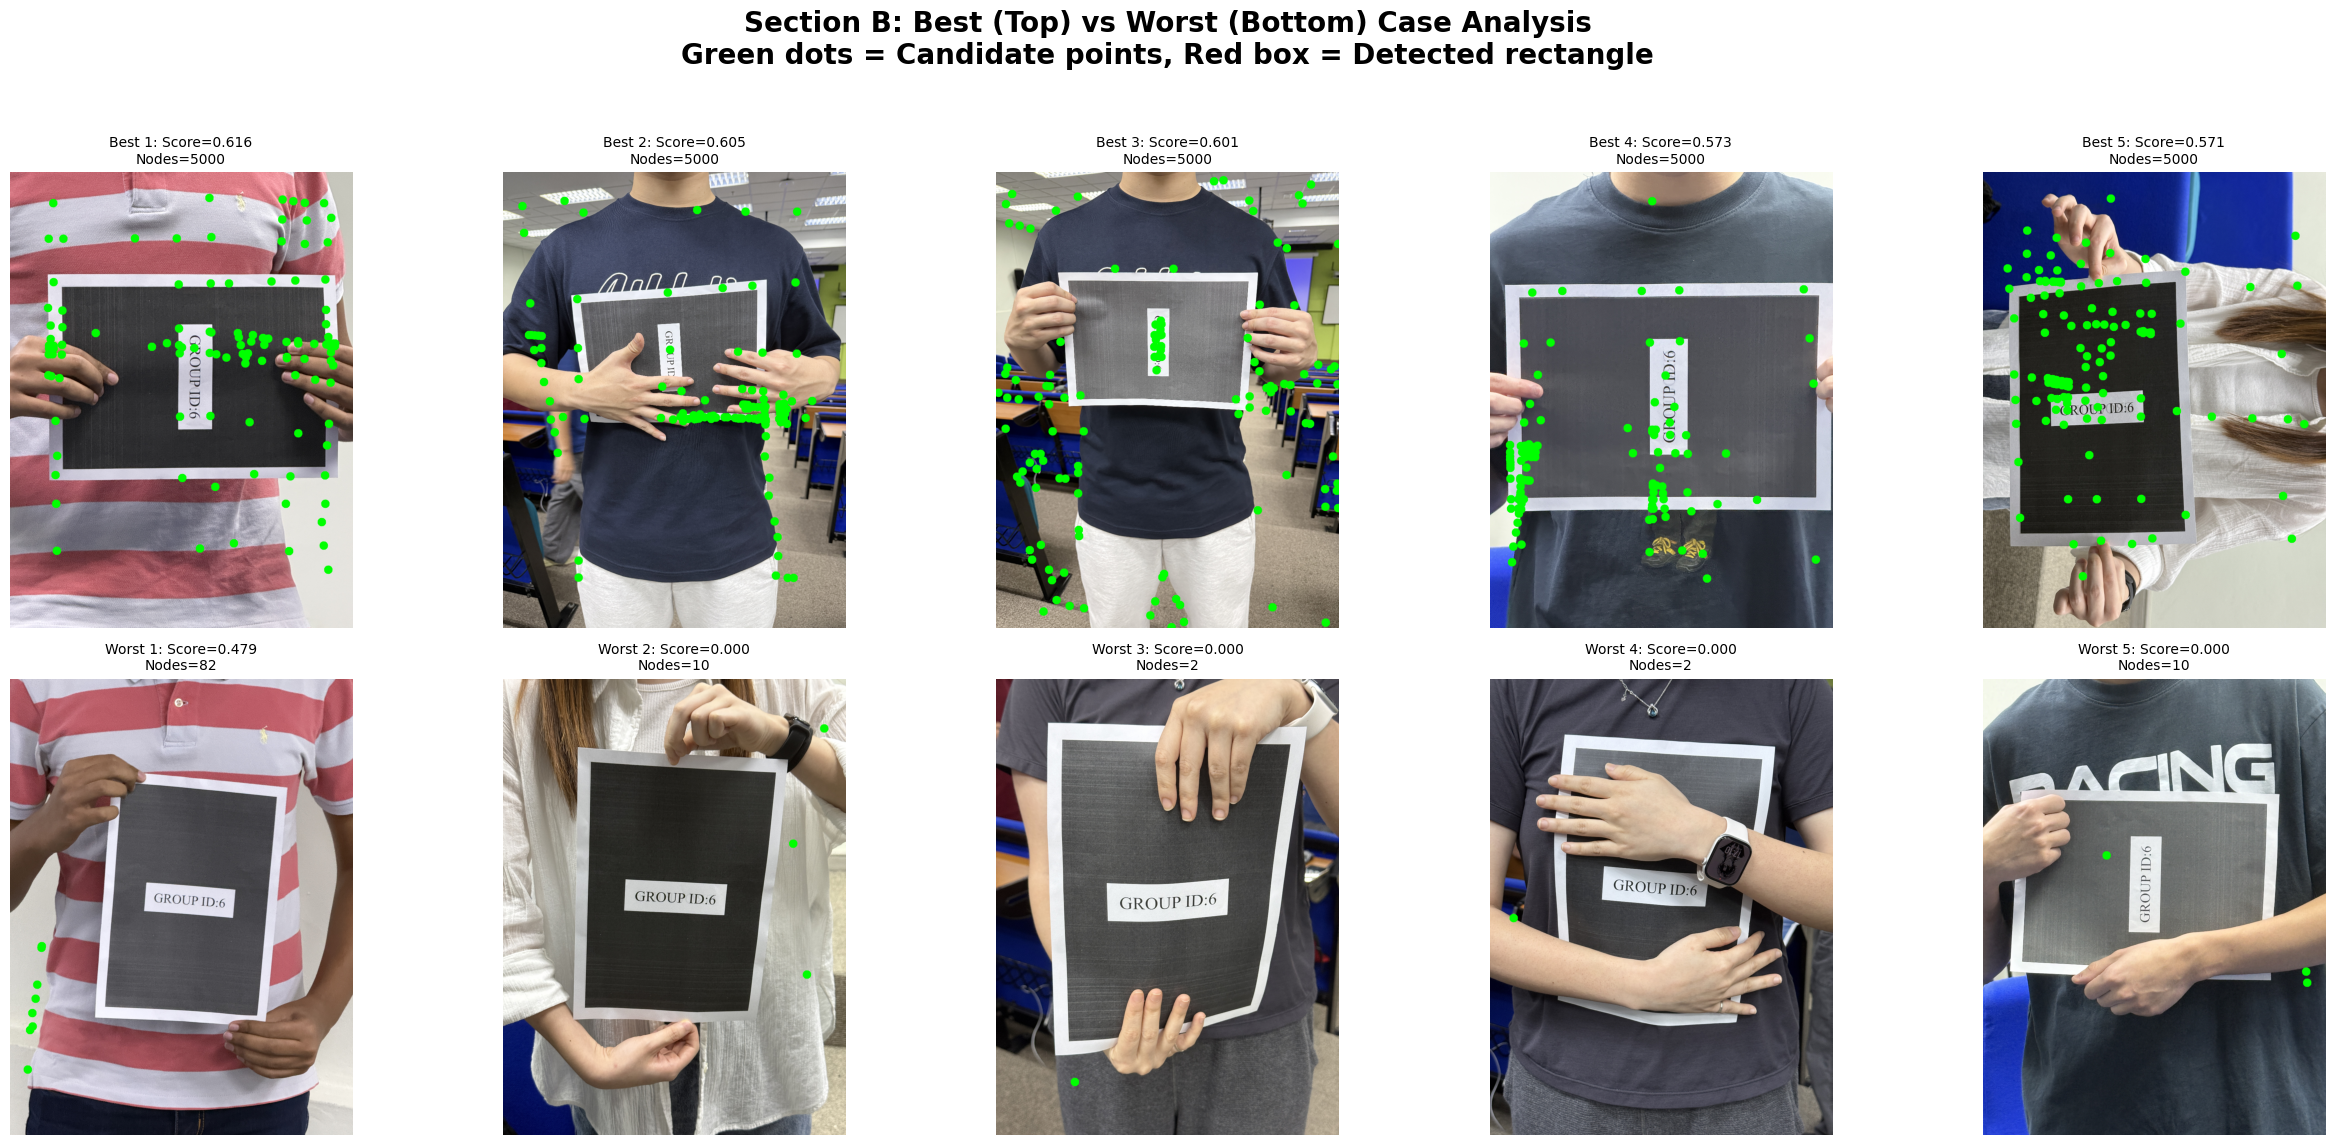

In [ ]:
image_folder = Path("Image")

# Helper function to overlay detected points and the final rectangle on the original image
def visualize_detection(image_path, candidates, rect, title):
    # Load and convert image color space
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Standardize orientation and resolution to match the search space
    if img.shape[0] < img.shape[1]:
        img = np.rot90(img, k=3)
    img = cv2.resize(img, (target_width, target_height))

    # Visualize Candidate Points, Draw green circles at each detected intersection
    radius = max(6, target_width // 80)
    for point in candidates:
        cv2.circle(img, tuple(point), radius, (0, 255, 0), -1)

    # Visualize Search Result: Draw the optimal A4 rectangle
    if rect is not None and len(rect) == 4:
        rect_points = rect.astype(int)
        for i in range(4):
            pt1 = tuple(rect_points[i])
            pt2 = tuple(rect_points[(i + 1) % 4])
            cv2.line(img, pt1, pt2, (255, 0, 0), 4)

    return img

# Filter data to analyze the Astar_h1 method specifically
h1_results = [r for r in all_rows if r["method"] == "Astar_h1"]
sorted_h1 = sorted(h1_results, key=lambda x: x["final_likelihood_score"], reverse=True)

# Identify the top 5 (Success cases) and bottom 5 (Failure cases) for comparison
num_to_plot = min(5, len(sorted_h1))
best_5 = sorted_h1[:num_to_plot]
worst_5 = sorted_h1[-num_to_plot:] if len(sorted_h1) >= 5 else []

# Create a 2x5 grid to display successes vs. failures side-by-side
fig, axes = plt.subplots(2, 5, figsize=(25, 12))
fig.suptitle("Section B: Best (Top) vs Worst (Bottom) Case Analysis\nGreen dots = Candidate points, Red box = Detected rectangle", 
             fontsize=20, fontweight='bold')

for i in range(num_to_plot):
    # Process and Plot Best Cases (Success Analysis)
    case_b = best_5[i]
    img_p_best = image_folder / case_b["image"]

    cands_b, mask_b, w_b, h_b = preprocess_candidates(img_p_best)
    _, rect_b, _ = astar_partBC(cands_b, mask_b, w_b, h_b, use_h2=False)

    img_best = visualize_detection(img_p_best, cands_b, rect_b,
                                   f"Best {i+1}: Score={case_b['final_likelihood_score']:.3f}\nNodes={case_b['nodes_expanded']}")
    axes[0, i].imshow(img_best)
    axes[0, i].set_title(f"Best {i+1}: Score={case_b['final_likelihood_score']:.3f}\nNodes={case_b['nodes_expanded']}", fontsize=10)
    axes[0, i].axis('off')

    # Process and Plot Worst Cases (Failure Analysis)
    if i < len(worst_5):
        case_w = worst_5[i]
        img_p_worst = image_folder / case_w["image"]
        cands_w, mask_w, w_w, h_w = preprocess_candidates(img_p_worst)
        _, rect_w, _ = astar_partBC(cands_w, mask_w, w_w, h_w, use_h2=False)
        
        img_worst = visualize_detection(img_p_worst, cands_w, rect_w,
                                        f"Worst {i+1}: Score={case_w['final_likelihood_score']:.3f}\nNodes={case_w['nodes_expanded']}")
        axes[1, i].imshow(img_worst)
        axes[1, i].set_title(f"Worst {i+1}: Score={case_w['final_likelihood_score']:.3f}\nNodes={case_w['nodes_expanded']}", fontsize=10)
        axes[1, i].axis('off')

# Final formatting, Clear unused axes and adjust layout
for i in range(num_to_plot, 5):
    axes[0, i].axis('off')
    axes[1, i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()